# CPG Product Intelligence - Report

* Data Extraction Date: July 22nd, 2026
* Source Dataset: Open Food Facts (Crowdsourced Open Dataset)

In [1]:
import pandas as pd

In [2]:
# Importing Datasets
cocacola = pd.read_csv(r'datasets\coca-cola_from_dump.csv')
fairlife = pd.read_csv(r'datasets\fairlife_from_dump.csv')
fanta = pd.read_csv(r'datasets\fanta_from_dump.csv')
maaza = pd.read_csv(r'datasets\maaza_from_dump.csv')
minutemaid = pd.read_csv(r'datasets\minute maid_from_dump.csv')
schweppes = pd.read_csv(r'datasets\schweppes_from_dump.csv')
sprite = pd.read_csv(r'datasets\sprite_from_dump.csv')
topochico = pd.read_csv(r'datasets\topo chico_from_dump.csv')

## Section 1: Global Overview

### Brand: Coca-Cola

In [ ]:
# ============================================================
# GENERIC CPG / BRAND — SECTION 1 GLOBAL OVERVIEW ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap


class GlobalAnalysis:

    # ========================================================
    # INITIALIZATION
    # ========================================================

    def __init__(
        self,
        df,
        brand="Unknown Brand",
        dataset_name=None
    ):
        """
        Generic analysis engine for CPG / beverage datasets.

        Parameters
        ----------
        df : pandas.DataFrame
            Dataset to analyze.

        brand : str
            Brand name shown in titles and insights.

        dataset_name : str, optional
            Dataset name. If not provided, brand name is used.

        Expected columns
        ----------------
        product_name
        countries_tags
        packaging_tags
        nutriscore_grade
        nova_group
        ecoscore_grade
        ingredients_text
        nutriments.sugars_100g
        nutriments.energy-kcal_100g
        """

        if not isinstance(df, pd.DataFrame):
            raise TypeError(
                "df must be a pandas DataFrame."
            )

        if df.empty:
            raise ValueError(
                "The supplied DataFrame is empty."
            )

        # ----------------------------------------------------
        # Store dataset
        # ----------------------------------------------------

        self.df = df.copy()

        self.brand = str(brand).strip()

        if not self.brand:
            self.brand = "Unknown Brand"

        self.dataset_name = (
            str(dataset_name).strip()
            if dataset_name
            else self.brand
        )

        # ----------------------------------------------------
        # Standard expected columns
        # ----------------------------------------------------

        self.expected_columns = [
            "product_name",
            "countries_tags",
            "packaging_tags",
            "nutriscore_grade",
            "nova_group",
            "ecoscore_grade",
            "ingredients_text",
            "nutriments.sugars_100g",
            "nutriments.energy-kcal_100g"
        ]

        # ----------------------------------------------------
        # Clean dataset
        # ----------------------------------------------------

        self._prepare_data()

        # ----------------------------------------------------
        # Plotting configuration
        # ----------------------------------------------------

        sns.set_theme(
            style="whitegrid",
            context="notebook"
        )

        plt.rcParams.update({
            "figure.figsize": (10, 6),
            "figure.dpi": 110,
            "savefig.dpi": 150,
            "axes.titleweight": "bold",
            "axes.titlesize": 15,
            "axes.labelsize": 11,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10
        })


    # ========================================================
    # DATA PREPARATION
    # ========================================================

    def _prepare_data(self):
        """
        Clean text/numeric columns and create exploded
        country and packaging DataFrames.
        """

        # ----------------------------------------------------
        # Text columns
        # ----------------------------------------------------

        text_columns = [
            "product_name",
            "countries_tags",
            "packaging_tags",
            "nutriscore_grade",
            "ecoscore_grade",
            "ingredients_text"
        ]

        for col in text_columns:

            if col in self.df.columns:

                self.df[col] = (
                    self.df[col]
                    .fillna("unknown")
                    .astype(str)
                    .str.strip()
                )

        # ----------------------------------------------------
        # Numeric columns
        # ----------------------------------------------------

        numeric_columns = [
            "nutriments.sugars_100g",
            "nutriments.energy-kcal_100g",
            "nova_group"
        ]

        for col in numeric_columns:

            if col in self.df.columns:

                self.df[col] = pd.to_numeric(
                    self.df[col],
                    errors="coerce"
                )

        # ----------------------------------------------------
        # Country dataframe
        # ----------------------------------------------------

        if "countries_tags" in self.df.columns:

            self.country_df = self.df.copy()

            self.country_df["countries_tags"] = (
                self.country_df["countries_tags"]
                .astype(str)
                .str.split(",")
            )

            self.country_df = (
                self.country_df
                .explode("countries_tags")
            )

            self.country_df["countries_tags"] = (
                self.country_df["countries_tags"]
                .astype(str)
                .str.strip()
                .str.lower()
            )

            self.country_df = self.country_df[
                ~self.country_df["countries_tags"].isin(
                    ["", "unknown", "nan", "none"]
                )
            ]

        else:

            self.country_df = pd.DataFrame(
                columns=["countries_tags"]
            )

        # ----------------------------------------------------
        # Packaging dataframe
        # ----------------------------------------------------

        if "packaging_tags" in self.df.columns:

            self.pack_df = self.df.copy()

            self.pack_df["packaging_tags"] = (
                self.pack_df["packaging_tags"]
                .astype(str)
                .str.split(",")
            )

            self.pack_df = (
                self.pack_df
                .explode("packaging_tags")
            )

            self.pack_df["packaging_tags"] = (
                self.pack_df["packaging_tags"]
                .astype(str)
                .str.strip()
                .str.lower()
            )

            self.pack_df = self.pack_df[
                ~self.pack_df["packaging_tags"].isin(
                    ["", "unknown", "nan", "none"]
                )
            ]

        else:

            self.pack_df = pd.DataFrame(
                columns=["packaging_tags"]
            )


    # ========================================================
    # HELPER — COLUMN CHECK
    # ========================================================

    def _require_column(self, column):
        """
        Check whether a required column exists.
        """

        if column not in self.df.columns:

            print(
                f"⚠️ Skipping analysis: "
                f"'{column}' column is not available."
            )

            return False

        return True


    # ========================================================
    # HELPER — CLEAN CATEGORIES
    # ========================================================

    def _clean_category(self, series):
        """
        Standardize categorical values.
        """

        return (
            series
            .fillna("unknown")
            .astype(str)
            .str.strip()
            .str.lower()
        )


    # ========================================================
    # HELPER — TITLE
    # ========================================================

    def _title(
        self,
        title,
        subtitle=None
    ):
        """
        Create clean chart titles.
        """

        if subtitle:

            full_title = (
                f"{title}\n"
                f"{subtitle}"
            )

        else:

            full_title = title

        plt.title(
            full_title,
            fontsize=15,
            fontweight="bold",
            pad=15,
            linespacing=1.4
        )

        plt.tight_layout(
            pad=2.0
        )


    # ========================================================
    # HELPER — INSIGHT
    # ========================================================

    def _description(
        self,
        text
    ):
        """
        Display wrapped insight text.
        """

        print("\n" + "-" * 75)

        print("INSIGHT")

        print("-" * 75)

        wrapped = textwrap.fill(
            str(text),
            width=85,
            break_long_words=False,
            break_on_hyphens=False
        )

        print(wrapped)

        print()


    # ========================================================
    # HELPER — VALUE LABELS
    # ========================================================

    def _add_value_labels(
        self,
        ax,
        decimals=0
    ):
        """
        Add values on bars.
        """

        for container in ax.containers:

            labels = []

            for bar in container:

                height = bar.get_height()

                if np.isnan(height):
                    labels.append("")
                    continue

                if decimals == 0:

                    labels.append(
                        f"{height:,.0f}"
                    )

                else:

                    labels.append(
                        f"{height:,.{decimals}f}"
                    )

            ax.bar_label(
                container,
                labels=labels,
                padding=3
            )


    # ========================================================
    # HELPER — PERCENTAGE
    # ========================================================

    def _percentage(
        self,
        value,
        total
    ):

        if total == 0:
            return 0

        return (
            value / total
        ) * 100


    # ========================================================
    # DATASET SUMMARY
    # ========================================================

    def dataset_summary(self):
        """
        Display high-level information about the dataset.
        """

        total_rows = len(self.df)

        available = [
            col for col in self.expected_columns
            if col in self.df.columns
        ]

        missing_columns = [
            col for col in self.expected_columns
            if col not in self.df.columns
        ]

        print("\n" + "=" * 75)

        print(
            f"{self.brand.upper()} — DATASET SUMMARY"
        )

        print("=" * 75)

        print(
            f"Dataset name       : {self.dataset_name}"
        )

        print(
            f"Rows               : {total_rows:,}"
        )

        print(
            f"Columns            : {self.df.shape[1]:,}"
        )

        print(
            f"Analysis columns   : "
            f"{len(available)}/{len(self.expected_columns)}"
        )

        if missing_columns:

            print(
                "\nMissing expected columns:"
            )

            for col in missing_columns:

                print(
                    f"  • {col}"
                )

        print("\nColumn completeness:")

        completeness = (
            self.df.notna()
            .mean()
            .mul(100)
            .sort_values()
        )

        print(
            completeness
            .round(1)
            .to_string()
        )

        print(
            "\n" + "=" * 75
        )


    # ========================================================
    # 1.1 GEOGRAPHIC FOOTPRINT
    # ========================================================

    def total_market_presence(self):
        """
        Total catalog records and distinct markets.
        """

        if "countries_tags" not in self.df.columns:

            self._description(
                "Geographic market analysis cannot be performed "
                "because countries_tags is unavailable."
            )

            return

        total_products = len(self.df)

        total_markets = (
            self.country_df["countries_tags"]
            .nunique()
        )

        values = [
            total_products,
            total_markets
        ]

        labels = [
            "Catalog Records",
            "Markets"
        ]

        fig, ax = plt.subplots(
            figsize=(10, 5)
        )

        bars = ax.bar(
            labels,
            values
        )

        ax.set_ylabel(
            "Count"
        )

        self._title(
            f"{self.brand} — Total Market Presence",
            "Catalog size compared with geographic market coverage"
        )

        ax.bar_label(
            bars,
            fmt="%.0f",
            padding=4
        )

        plt.show()

        self._description(
            f"The {self.brand} dataset contains "
            f"{total_products:,} catalog records associated "
            f"with {total_markets:,} distinct markets. "
            f"This measures geographic representation in the "
            f"dataset and should not be interpreted as verified "
            f"commercial distribution or market share."
        )


    # ========================================================
    # MARKET DENSITY
    # ========================================================

    def market_density_distribution(
        self,
        top_n=15
    ):
        """
        Top markets by catalog record density.
        """

        if self.country_df.empty:

            self._description(
                "No usable country information is available."
            )

            return

        counts = (
            self.country_df[
                "countries_tags"
            ]
            .value_counts()
            .head(top_n)
            .sort_values()
        )

        fig, ax = plt.subplots(
            figsize=(11, 7)
        )

        bars = ax.barh(
            counts.index,
            counts.values
        )

        ax.set_xlabel(
            "Number of Catalog Records"
        )

        ax.set_ylabel(
            "Market"
        )

        self._title(
            f"{self.brand} — Market Density Distribution",
            f"Top {top_n} markets by catalog representation"
        )

        ax.bar_label(
            bars,
            fmt="%.0f",
            padding=4
        )

        plt.show()

        top_market = counts.idxmax()
        top_value = counts.max()

        share = self._percentage(
            top_value,
            self.country_df["countries_tags"].value_counts().sum()
        )

        self._description(
            f"{top_market.title()} has the highest catalog density "
            f"with {top_value:,} records. It represents approximately "
            f"{share:.1f}% of all country-tagged catalog observations "
            f"in the analyzed dataset. Catalog density reflects data "
            f"coverage, not sales volume or market share."
        )


    # ========================================================
    # PORTFOLIO DISTRIBUTION
    # ========================================================

    def portfolio_distribution_nature(self):
        """
        Classify catalog records based on number of associated markets.

        Categories:
        - Single-market
        - Multi-market
        - Unknown

        IMPORTANT:
        Multi-market tagging does NOT prove identical formulations.
        """

        if "countries_tags" not in self.df.columns:

            self._description(
                "Portfolio localization analysis requires "
                "countries_tags."
            )

            return

        market_counts = (
            self.df["countries_tags"]
            .fillna("unknown")
            .astype(str)
            .apply(
                lambda x: len([
                    c
                    for c in x.split(",")
                    if c.strip()
                    and c.strip().lower()
                    not in [
                        "unknown",
                        "nan",
                        "none"
                    ]
                ])
            )
        )

        single_market = (
            market_counts == 1
        ).sum()

        multi_market = (
            market_counts > 1
        ).sum()

        unknown = (
            market_counts == 0
        ).sum()

        result = pd.Series({
            "Single-market": single_market,
            "Multi-market": multi_market,
            "Unknown": unknown
        })

        fig, ax = plt.subplots(
            figsize=(9, 6)
        )

        bars = ax.bar(
            result.index,
            result.values
        )

        ax.set_xlabel(
            "Portfolio Classification"
        )

        ax.set_ylabel(
            "Catalog Records"
        )

        self._title(
            f"{self.brand} — Portfolio Distribution Nature",
            "Single-market versus multi-market product records"
        )

        ax.bar_label(
            bars,
            fmt="%.0f",
            padding=4
        )

        plt.show()

        total = len(self.df)

        single_pct = self._percentage(
            single_market,
            total
        )

        multi_pct = self._percentage(
            multi_market,
            total
        )

        self._description(
            f"{single_market:,} records "
            f"({single_pct:.1f}%) are associated with a single market, "
            f"while {multi_market:,} records "
            f"({multi_pct:.1f}%) are associated with multiple markets. "
            f"This is a dataset-based localization proxy. "
            f"Multi-market tagging does not prove that the formulation "
            f"is identical across those markets."
        )


    # ========================================================
    # MARKET DEPTH
    # ========================================================

    def formulation_market_depth(
        self,
        top_n=10
    ):
        """
        Distribution of the number of markets associated with
        each product record.
        """

        if "countries_tags" not in self.df.columns:

            return

        market_depth = (
            self.df["countries_tags"]
            .fillna("unknown")
            .astype(str)
            .apply(
                lambda x: len([
                    c
                    for c in x.split(",")
                    if c.strip()
                    and c.strip().lower()
                    not in [
                        "unknown",
                        "nan",
                        "none"
                    ]
                ])
            )
        )

        counts = (
            market_depth
            .value_counts()
            .sort_index()
        )

        counts = counts.head(
            top_n
        )

        fig, ax = plt.subplots(
            figsize=(11, 6)
        )

        bars = ax.bar(
            counts.index.astype(str),
            counts.values
        )

        ax.set_xlabel(
            "Number of Associated Markets"
        )

        ax.set_ylabel(
            "Catalog Records"
        )

        self._title(
            f"{self.brand} — Market Depth",
            "Number of markets associated with each catalog record"
        )

        ax.bar_label(
            bars,
            fmt="%.0f",
            padding=4
        )

        plt.show()

        self._description(
            "This analysis measures how many country tags are "
            "associated with each catalog record. A record linked "
            "to one country is more localized in the dataset, while "
            "records linked to multiple countries have broader "
            "geographic tagging. This does not independently establish "
            "formulation equivalence."
        )


    # ========================================================
    # 1.2 HEALTH & NUTRITION
    # ========================================================

    def sugar_profiling(
        self,
        bins=None
    ):
        """
        Sugar distribution per 100g.
        """

        col = "nutriments.sugars_100g"

        if not self._require_column(col):

            return

        data = (
            self.df[col]
            .dropna()
        )

        if data.empty:

            self._description(
                "No usable sugar measurements are available."
            )

            return

        if bins is None:

            bins = [
                -np.inf,
                1,
                5,
                10,
                20,
                30,
                40,
                50,
                np.inf
            ]

        labels = [
            "<1",
            "1–5",
            "5–10",
            "10–20",
            "20–30",
            "30–40",
            "40–50",
            "50+"
        ]

        groups = pd.cut(
            data,
            bins=bins,
            labels=labels
        )

        counts = (
            groups
            .value_counts(
                sort=False
            )
        )

        fig, ax = plt.subplots(
            figsize=(11, 6)
        )

        bars = ax.bar(
            counts.index.astype(str),
            counts.values
        )

        ax.set_xlabel(
            "Sugar (g per 100g)"
        )

        ax.set_ylabel(
            "Number of Products"
        )

        self._title(
            f"{self.brand} — Sugar Profiling",
            "Distribution of reported sugar concentration per 100g"
        )

        ax.bar_label(
            bars,
            fmt="%.0f",
            padding=4
        )

        plt.show()

        coverage = self._percentage(
            len(data),
            len(self.df)
        )

        self._description(
            f"Sugar values are available for {len(data):,} "
            f"of {len(self.df):,} records ({coverage:.1f}% coverage). "
            f"The median reported sugar concentration is "
            f"{data.median():.1f} g/100g, while the mean is "
            f"{data.mean():.1f} g/100g. "
            f"Because missing nutritional values are excluded, "
            f"this distribution describes only records with "
            f"reported measurements."
        )


    # ========================================================
    # CALORIC DENSITY
    # ========================================================

    def caloric_density(self):

        col = (
            "nutriments.energy-kcal_100g"
        )

        if not self._require_column(col):

            return

        data = (
            self.df[col]
            .dropna()
        )

        if data.empty:

            self._description(
                "No usable caloric measurements are available."
            )

            return

        fig, ax = plt.subplots(
            figsize=(11, 6)
        )

        sns.histplot(
            data,
            bins=30,
            kde=True,
            ax=ax
        )

        ax.set_xlabel(
            "Energy (kcal per 100g)"
        )

        ax.set_ylabel(
            "Number of Products"
        )

        self._title(
            f"{self.brand} — Caloric Density",
            "Distribution of reported energy density"
        )

        plt.show()

        coverage = self._percentage(
            len(data),
            len(self.df)
        )

        self._description(
            f"Energy values are available for {len(data):,} "
            f"records ({coverage:.1f}% coverage). "
            f"The median reported caloric density is "
            f"{data.median():.1f} kcal/100g, while the mean is "
            f"{data.mean():.1f} kcal/100g. "
            f"Missing measurements limit portfolio-wide inference."
        )


    # ========================================================
    # SUGAR VS CALORIES
    # ========================================================

    def nutrition_sugar_vs_calories(self):

        sugar_col = (
            "nutriments.sugars_100g"
        )

        kcal_col = (
            "nutriments.energy-kcal_100g"
        )

        if not self._require_column(
            sugar_col
        ):
            return

        if not self._require_column(
            kcal_col
        ):
            return

        data = self.df[
            [
                sugar_col,
                kcal_col
            ]
        ].dropna()

        if data.empty:

            self._description(
                "Insufficient paired sugar and caloric "
                "measurements for correlation analysis."
            )

            return

        fig, ax = plt.subplots(
            figsize=(10, 7)
        )

        sns.scatterplot(
            data=data,
            x=sugar_col,
            y=kcal_col,
            alpha=0.55,
            ax=ax
        )

        ax.set_xlabel(
            "Sugar (g/100g)"
        )

        ax.set_ylabel(
            "Energy (kcal/100g)"
        )

        self._title(
            f"{self.brand} — Sugar vs. Caloric Density",
            "Relationship between reported sugar and energy content"
        )

        plt.show()

        correlation = data[
            sugar_col
        ].corr(
            data[kcal_col]
        )

        self._description(
            f"Among {len(data):,} records containing both "
            f"measurements, the Pearson correlation between sugar "
            f"and energy density is {correlation:.2f}. "
            f"This describes the relationship in the available "
            f"catalog records and does not imply causation."
        )


    # ========================================================
    # NUTRI-SCORE
    # ========================================================

    def nutriscore_rating(self):

        col = "nutriscore_grade"

        if not self._require_column(col):

            return

        grades = self._clean_category(
            self.df[col]
        )

        unknown_values = [
            "",
            "unknown",
            "nan",
            "none"
        ]

        known = grades[
            ~grades.isin(
                unknown_values
            )
        ]

        order = [
            "a",
            "b",
            "c",
            "d",
            "e"
        ]

        counts = (
            known
            .value_counts()
            .reindex(
                order,
                fill_value=0
            )
        )

        fig, ax = plt.subplots(
            figsize=(10, 6)
        )

        bars = ax.bar(
            counts.index,
            counts.values
        )

        ax.set_xlabel(
            "Nutri-Score Grade"
        )

        ax.set_ylabel(
            "Number of Products"
        )

        self._title(
            f"{self.brand} — Nutri-Score Rating",
            "Reported nutritional rating across the portfolio"
        )

        ax.bar_label(
            bars,
            fmt="%.0f",
            padding=4
        )

        plt.show()

        coverage = self._percentage(
            len(known),
            len(grades)
        )

        if len(known) > 0:

            dominant = (
                known
                .value_counts()
                .idxmax()
            )

            self._description(
                f"Nutri-Score is available for "
                f"{len(known):,} of {len(grades):,} records "
                f"({coverage:.1f}% coverage). "
                f"The most frequent reported grade is "
                f"{dominant.upper()}. "
                f"Unknown or unreported values are excluded "
                f"from the grade comparison rather than treated "
                f"as a nutritional rating."
            )

        else:

            self._description(
                "No usable Nutri-Score values were found."
            )


    # ========================================================
    # NOVA PROCESSING
    # ========================================================

    def nova_processing_level(self):

        col = "nova_group"

        if not self._require_column(col):

            return

        data = pd.to_numeric(
            self.df[col],
            errors="coerce"
        ).dropna()

        if data.empty:

            self._description(
                "No usable NOVA classification data is available."
            )

            return

        counts = (
            data
            .astype(int)
            .value_counts()
            .sort_index()
        )

        labels = [
            f"NOVA {int(x)}"
            for x in counts.index
        ]

        fig, ax = plt.subplots(
            figsize=(9, 6)
        )

        bars = ax.bar(
            labels,
            counts.values
        )

        ax.set_xlabel(
            "Processing Level"
        )

        ax.set_ylabel(
            "Number of Products"
        )

        self._title(
            f"{self.brand} — NOVA Processing Level",
            "Distribution of reported food-processing classifications"
        )

        ax.bar_label(
            bars,
            fmt="%.0f",
            padding=4
        )

        plt.show()

        coverage = self._percentage(
            len(data),
            len(self.df)
        )

        dominant = (
            data
            .mode()
            .iloc[0]
        )

        self._description(
            f"NOVA classification is available for "
            f"{len(data):,} of {len(self.df):,} records "
            f"({coverage:.1f}% coverage). "
            f"NOVA group {int(dominant)} is the most frequently "
            f"reported processing category. "
            f"Because NOVA data is incomplete, this should not "
            f"be interpreted as a complete classification of "
            f"the entire portfolio."
        )


    # ========================================================
    # 1.4 PACKAGING
    # ========================================================

    def packaging_substrates(
        self,
        top_n=15
    ):
        """
        Analyze top packaging tags.
        """

        if self.pack_df.empty:

            self._description(
                "No usable packaging information is available."
            )

            return

        counts = (
            self.pack_df[
                "packaging_tags"
            ]
            .value_counts()
            .head(top_n)
            .sort_values()
        )

        fig, ax = plt.subplots(
            figsize=(11, 7)
        )

        bars = ax.barh(
            counts.index,
            counts.values
        )

        ax.set_xlabel(
            "Number of Packaging Records"
        )

        ax.set_ylabel(
            "Packaging Type"
        )

        self._title(
            f"{self.brand} — Primary Packaging Substrates",
            f"Top {top_n} reported packaging types"
        )

        ax.bar_label(
            bars,
            fmt="%.0f",
            padding=4
        )

        plt.show()

        top_packaging = counts.idxmax()

        self._description(
            f"The most frequently reported packaging tag is "
            f"'{top_packaging}'. "
            f"Packaging metadata contains multiple detailed "
            f"format and material tags, so these counts represent "
            f"reported catalog metadata rather than physical "
            f"packaging volumes."
        )


    # ========================================================
    # ECO-SCORE
    # ========================================================

    def ecoscore_transparency(self):

        col = "ecoscore_grade"

        if not self._require_column(col):

            return

        grades = self._clean_category(
            self.df[col]
        )

        unknown_values = [
            "",
            "unknown",
            "nan",
            "none"
        ]

        known = grades[
            ~grades.isin(
                unknown_values
            )
        ]

        unknown_count = (
            len(grades)
            - len(known)
        )

        if not known.empty:

            counts = (
                known
                .value_counts()
            )

            fig, ax = plt.subplots(
                figsize=(10, 6)
            )

            bars = ax.bar(
                counts.index,
                counts.values
            )

            ax.set_xlabel(
                "Eco-Score Grade"
            )

            ax.set_ylabel(
                "Number of Products"
            )

            self._title(
                f"{self.brand} — Eco-Score Distribution",
                "Reported environmental scoring data"
            )

            ax.bar_label(
                bars,
                fmt="%.0f",
                padding=4
            )

            plt.show()

        coverage = self._percentage(
            len(known),
            len(grades)
        )

        self._description(
            f"Eco-Score information is available for "
            f"{len(known):,} of {len(grades):,} records "
            f"({coverage:.1f}% coverage). "
            f"{unknown_count:,} records do not contain a usable "
            f"Eco-Score grade. Therefore, data availability itself "
            f"is an important indicator of environmental-data "
            f"transparency in the catalog."
        )


    # ========================================================
    # PACKAGING DATA COVERAGE
    # ========================================================

    def packaging_data_transparency(self):

        if "packaging_tags" not in self.df.columns:

            return

        values = self._clean_category(
            self.df["packaging_tags"]
        )

        known = ~values.isin(
            [
                "",
                "unknown",
                "nan",
                "none"
            ]
        )

        available = known.sum()
        missing = (~known).sum()

        result = pd.Series({
            "Reported": available,
            "Missing": missing
        })

        fig, ax = plt.subplots(
            figsize=(8, 6)
        )

        bars = ax.bar(
            result.index,
            result.values
        )

        ax.set_ylabel(
            "Catalog Records"
        )

        self._title(
            f"{self.brand} — Packaging Data Transparency",
            "Availability of packaging metadata"
        )

        ax.bar_label(
            bars,
            fmt="%.0f",
            padding=4
        )

        plt.show()

        coverage = self._percentage(
            available,
            len(self.df)
        )

        self._description(
            f"Packaging information is available for "
            f"{available:,} records ({coverage:.1f}%). "
            f"{missing:,} records do not contain usable packaging "
            f"metadata. This distinction is important because "
            f"packaging frequency charts only represent records "
            f"where packaging information was reported."
        )


    # ========================================================
    # NUTRITION DATA TRANSPARENCY
    # ========================================================

    def nutrition_data_transparency(self):

        sugar_col = (
            "nutriments.sugars_100g"
        )

        kcal_col = (
            "nutriments.energy-kcal_100g"
        )

        available_columns = []

        if sugar_col in self.df.columns:
            available_columns.append(
                "Sugar"
            )

        if kcal_col in self.df.columns:
            available_columns.append(
                "Calories"
            )

        if not available_columns:

            self._description(
                "No nutritional measurement columns are available."
            )

            return

        result = {}

        for label, col in [
            ("Sugar", sugar_col),
            ("Calories", kcal_col)
        ]:

            if col in self.df.columns:

                result[label] = (
                    self.df[col]
                    .notna()
                    .sum()
                )

        result = pd.Series(result)

        fig, ax = plt.subplots(
            figsize=(9, 6)
        )

        bars = ax.bar(
            result.index,
            result.values
        )

        ax.set_ylabel(
            "Records With Reported Data"
        )

        self._title(
            f"{self.brand} — Nutrition Data Transparency",
            "Availability of reported nutritional measurements"
        )

        ax.bar_label(
            bars,
            fmt="%.0f",
            padding=4
        )

        plt.show()

        descriptions = []

        for label, count in result.items():

            pct = self._percentage(
                count,
                len(self.df)
            )

            descriptions.append(
                f"{label}: {count:,} "
                f"({pct:.1f}%)"
            )

        self._description(
            " | ".join(descriptions)
            + ". Missing nutritional data is excluded from "
            "distribution calculations rather than treated as zero."
        )

In [4]:
coco = GlobalAnalysis(
    cocacola,
    brand="Coca-Cola"
)

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

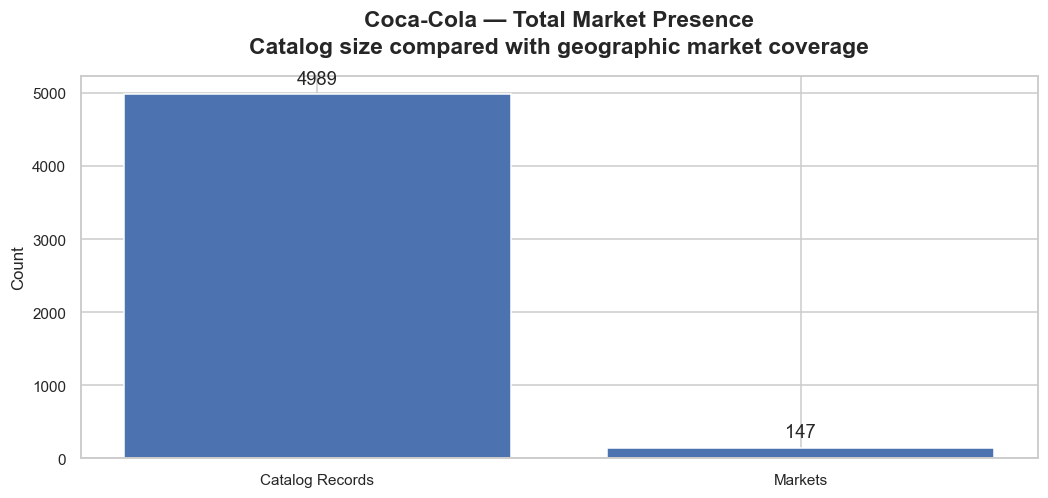


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
The Coca-Cola dataset contains 4,989 catalog records associated with 147 distinct
markets. This measures geographic representation in the dataset and should not be
interpreted as verified commercial distribution or market share.



In [5]:
coco.total_market_presence()

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

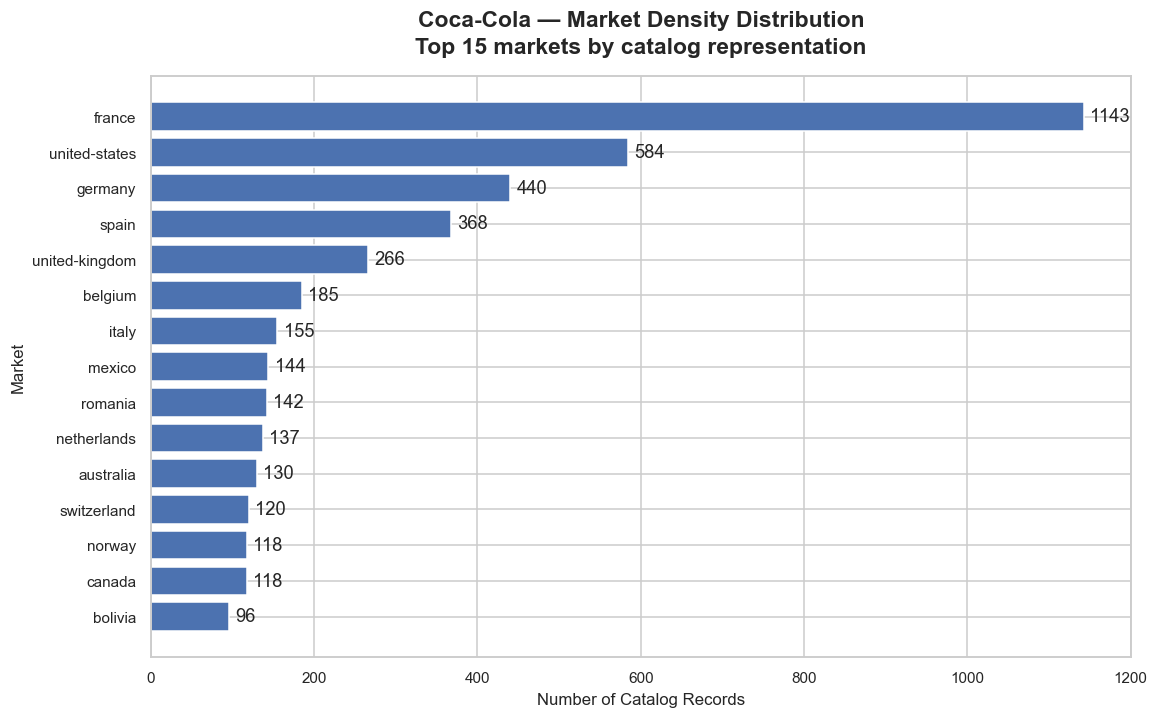


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
France has the highest catalog density with 1,143 records. It represents
approximately 18.9% of all country-tagged catalog observations in the analyzed
dataset. Catalog density reflects data coverage, not sales volume or market share.



In [6]:
coco.market_density_distribution(top_n=15)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

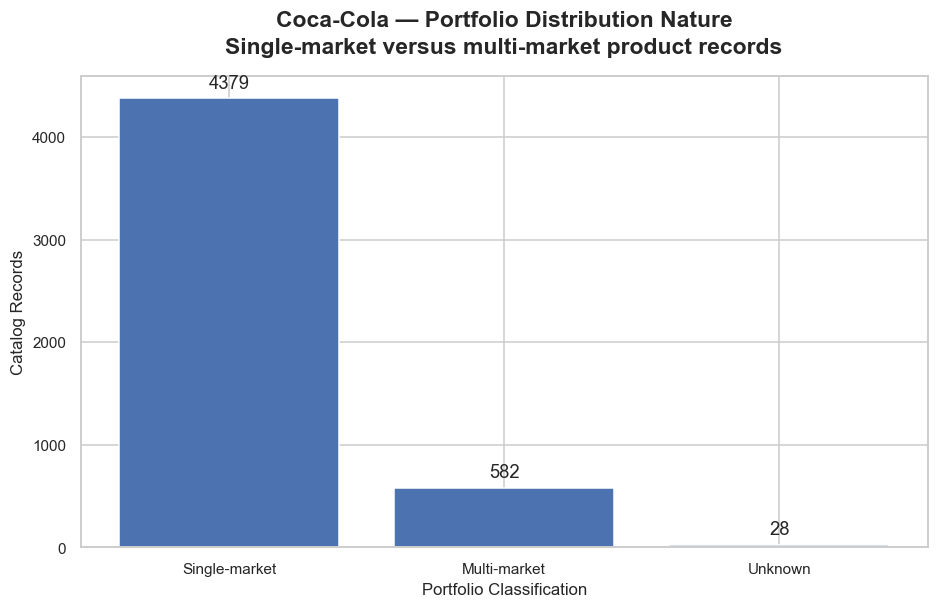


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
4,379 records (87.8%) are associated with a single market, while 582 records (11.7%)
are associated with multiple markets. This is a dataset-based localization proxy.
Multi-market tagging does not prove that the formulation is identical across those
markets.



In [7]:
coco.portfolio_distribution_nature()

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

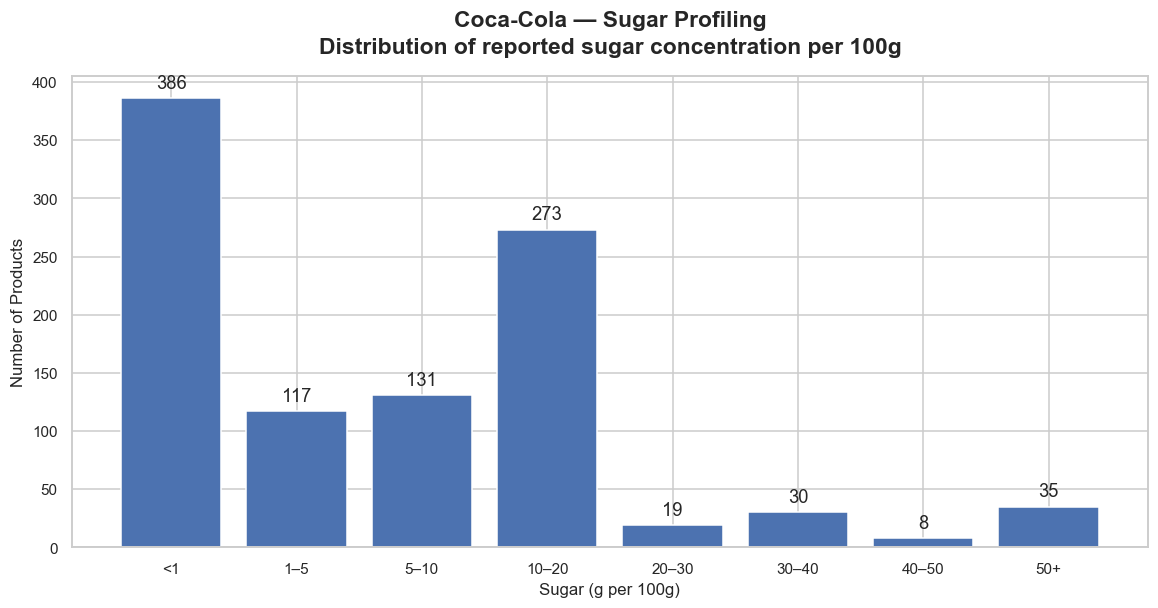


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
Sugar values are available for 999 of 4,989 records (20.0% coverage). The median
reported sugar concentration is 4.8 g/100g, while the mean is 9.0 g/100g. Because
missing nutritional values are excluded, this distribution describes only records
with reported measurements.



In [8]:
coco.sugar_profiling()

##### Caloric Density

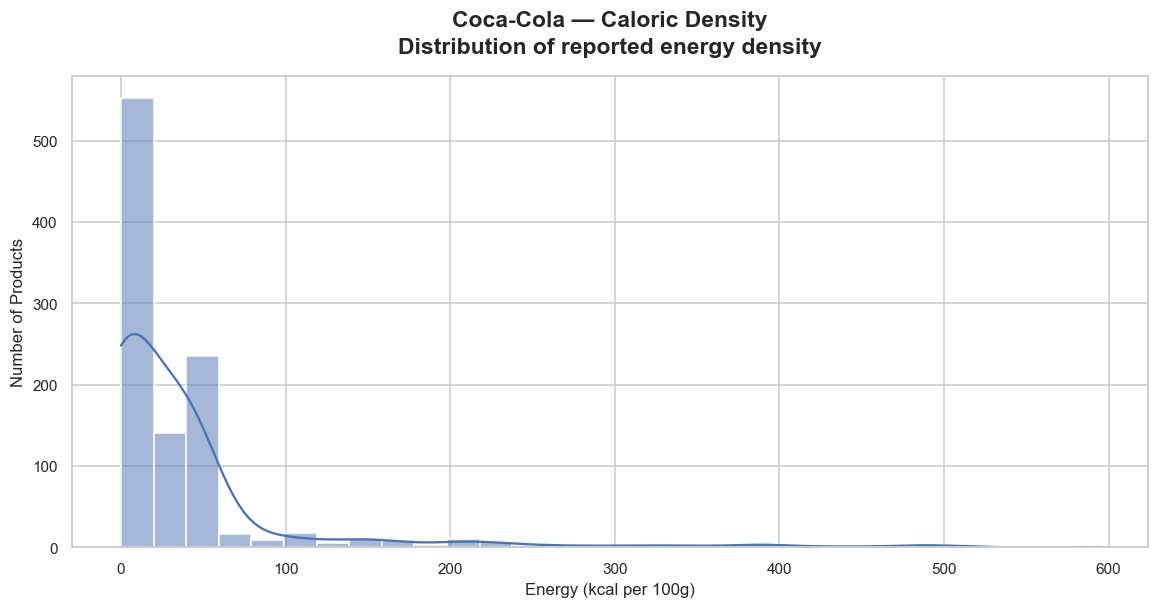


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
Energy values are available for 1,049 records (21.0% coverage). The median reported
caloric density is 16.7 kcal/100g, while the mean is 38.5 kcal/100g. Missing
measurements limit portfolio-wide inference.



In [9]:
coco.caloric_density()

##### Nutri-Score Rating

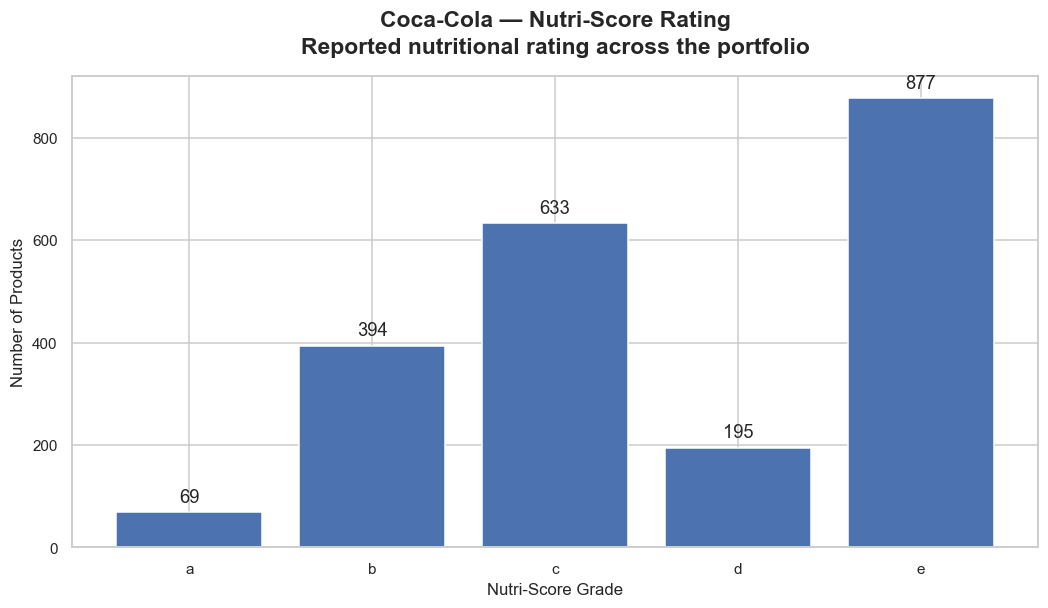


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
Nutri-Score is available for 2,180 of 4,989 records (43.7% coverage). The most
frequent reported grade is E. Unknown or unreported values are excluded from the
grade comparison rather than treated as a nutritional rating.



In [10]:
coco.nutriscore_rating()

#### 1.3 Formulation & Processing

##### NOVA Processing Level

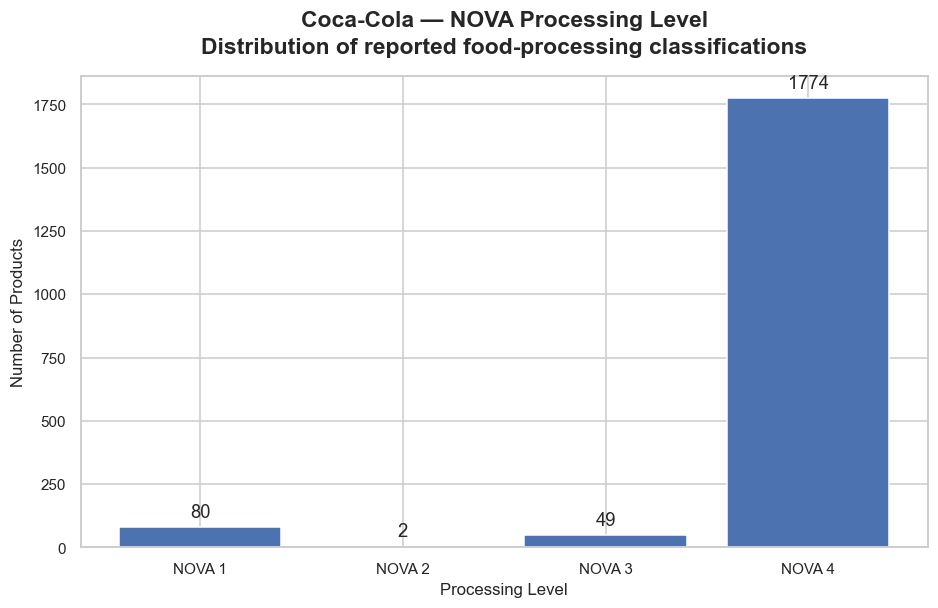


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
NOVA classification is available for 1,905 of 4,989 records (38.2% coverage). NOVA
group 4 is the most frequently reported processing category. Because NOVA data is
incomplete, this should not be interpreted as a complete classification of the entire
portfolio.



In [11]:
coco.nova_processing_level()

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

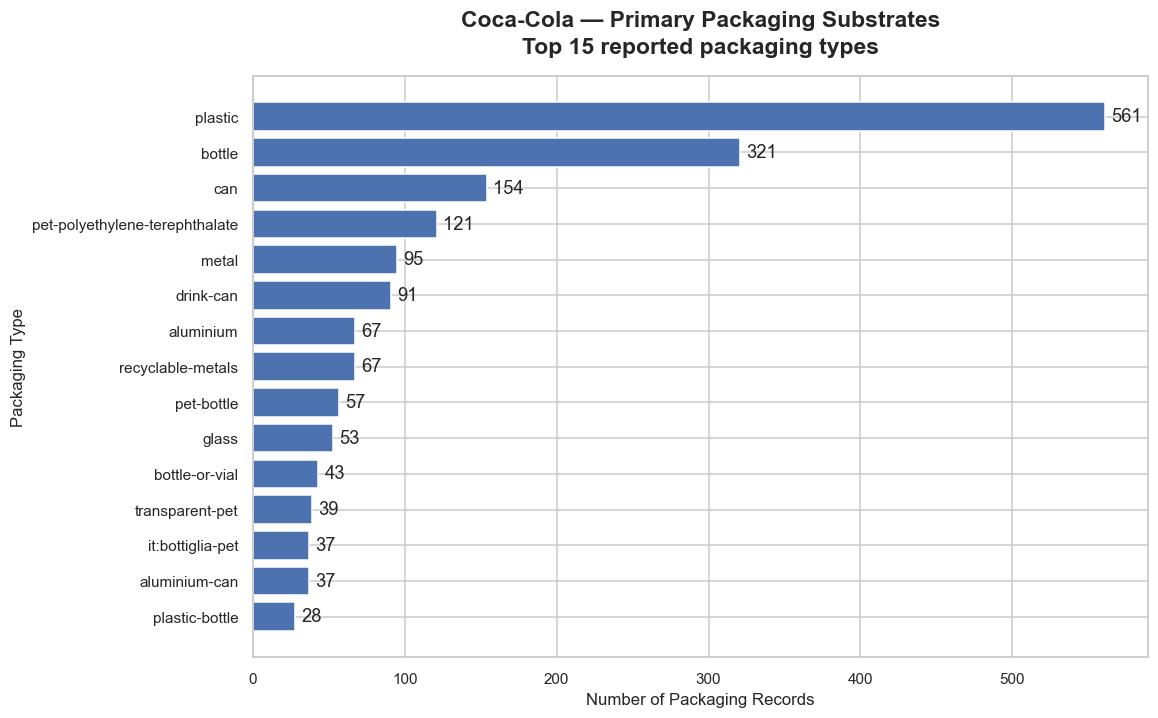


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
The most frequently reported packaging tag is 'plastic'. Packaging metadata contains
multiple detailed format and material tags, so these counts represent reported
catalog metadata rather than physical packaging volumes.



In [12]:
coco.packaging_substrates()

##### Environmental Data Transparency (Eco-Score)

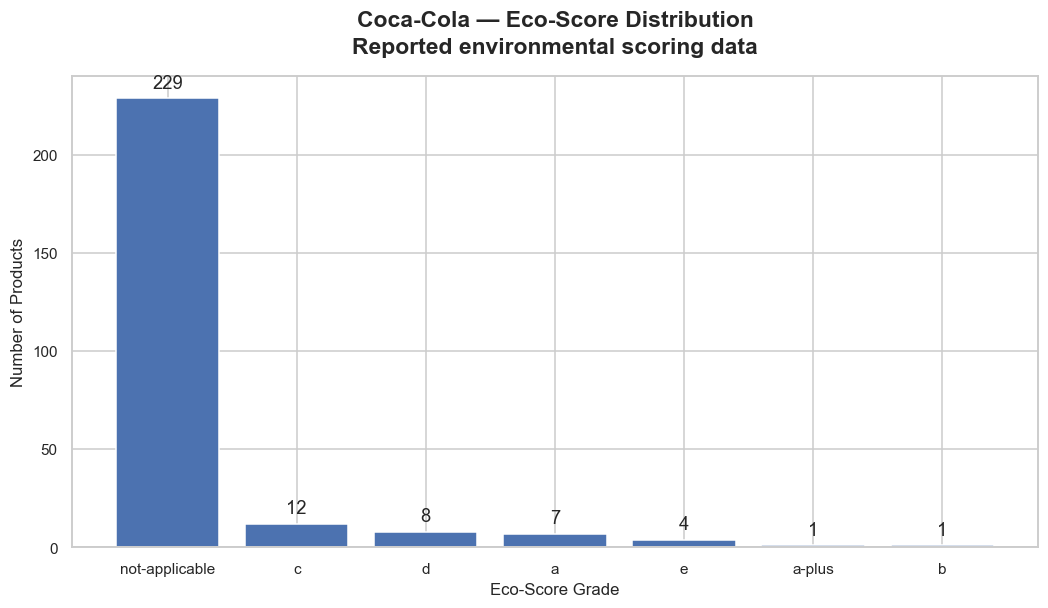


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
Eco-Score information is available for 262 of 4,989 records (5.3% coverage). 4,727
records do not contain a usable Eco-Score grade. Therefore, data availability itself
is an important indicator of environmental-data transparency in the catalog.



In [13]:
coco.ecoscore_transparency()

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

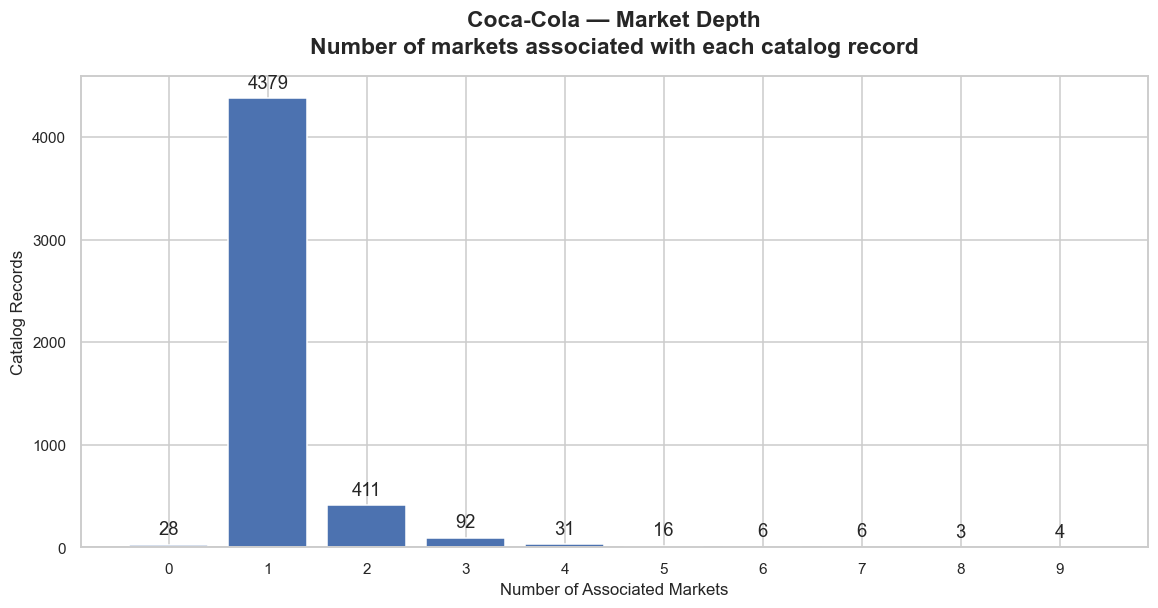


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
This analysis measures how many country tags are associated with each catalog record.
A record linked to one country is more localized in the dataset, while records linked
to multiple countries have broader geographic tagging. This does not independently
establish formulation equivalence.



In [14]:
coco.formulation_market_depth()

### Brand: Fairlife

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Fanta

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Maaza

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Minute-Maid

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Schweppes

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Sprite

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Topo Chico

In [21]:
tc = GlobalAnalysis(
    topochico,
    brand="Topochico"
)

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

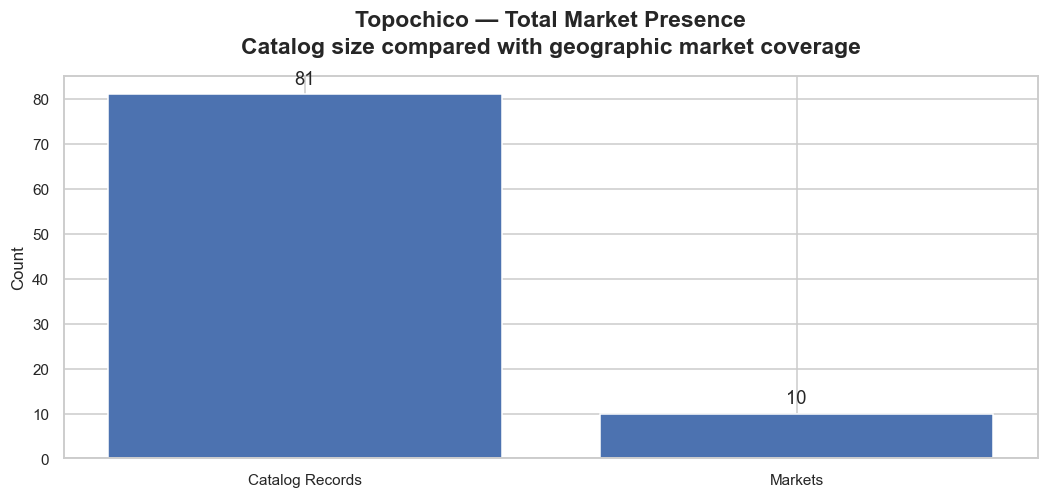


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
The Topochico dataset contains 81 catalog records associated with 10 distinct
markets. This measures geographic representation in the dataset and should not be
interpreted as verified commercial distribution or market share.



In [22]:
tc.total_market_presence()

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

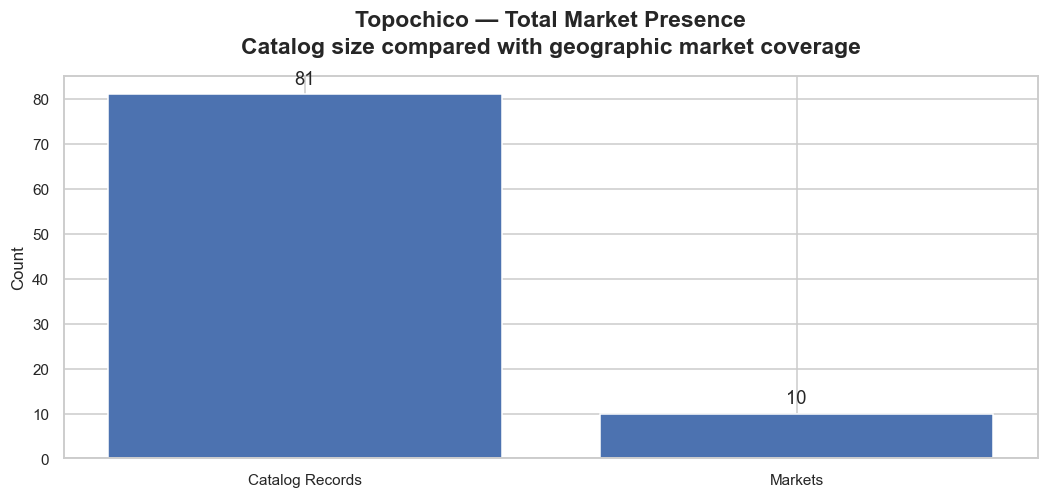


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
The Topochico dataset contains 81 catalog records associated with 10 distinct
markets. This measures geographic representation in the dataset and should not be
interpreted as verified commercial distribution or market share.



In [23]:
tc.total_market_presence()

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

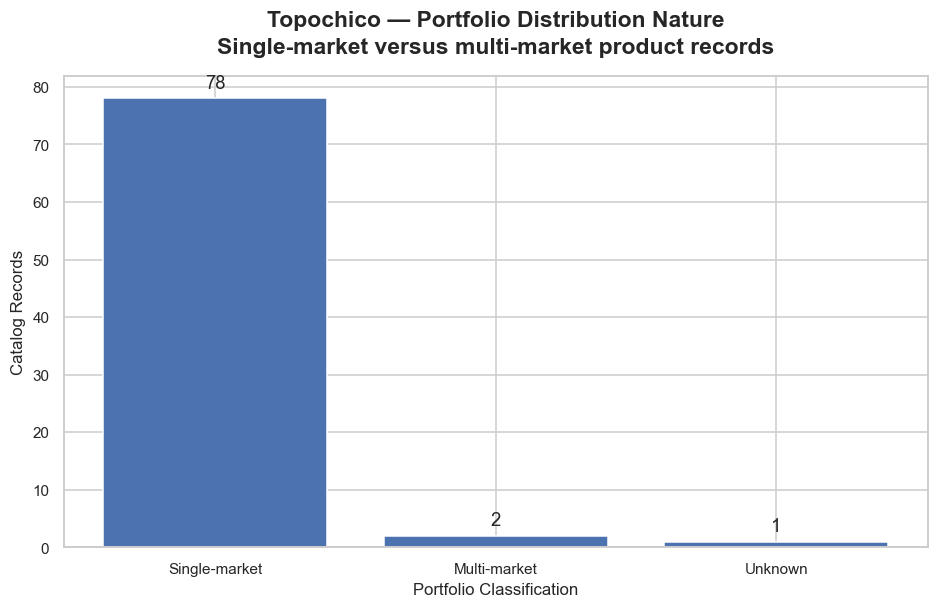


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
78 records (96.3%) are associated with a single market, while 2 records (2.5%) are
associated with multiple markets. This is a dataset-based localization proxy.
Multi-market tagging does not prove that the formulation is identical across those
markets.



In [24]:
tc.portfolio_distribution_nature()

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

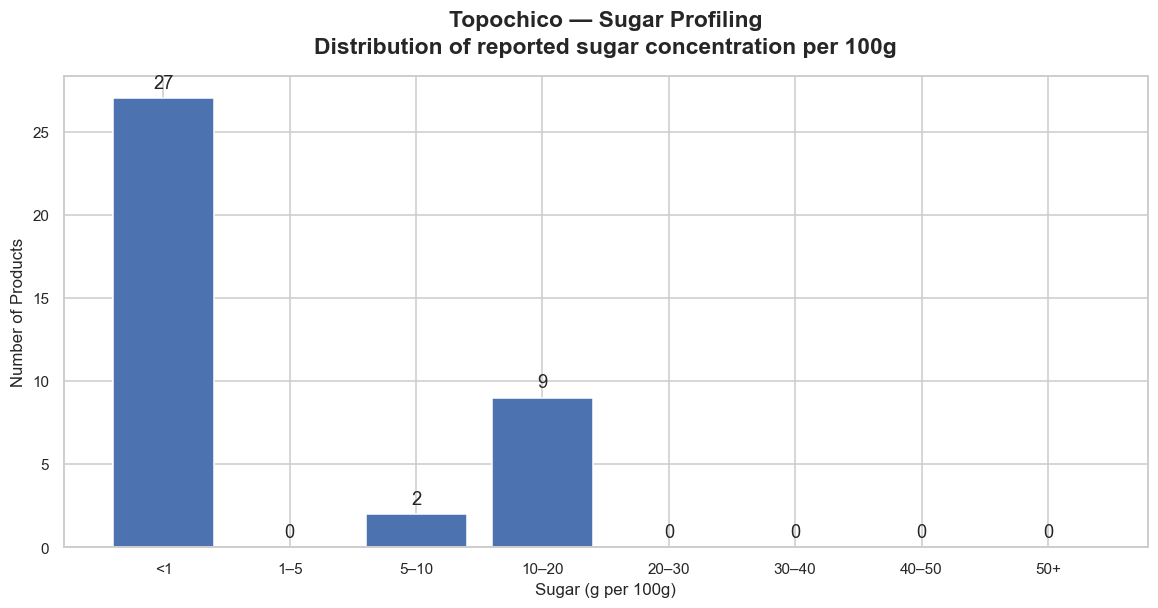


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
Sugar values are available for 38 of 81 records (46.9% coverage). The median reported
sugar concentration is 0.3 g/100g, while the mean is 3.2 g/100g. Because missing
nutritional values are excluded, this distribution describes only records with
reported measurements.



In [25]:
tc.sugar_profiling()

##### Caloric Density

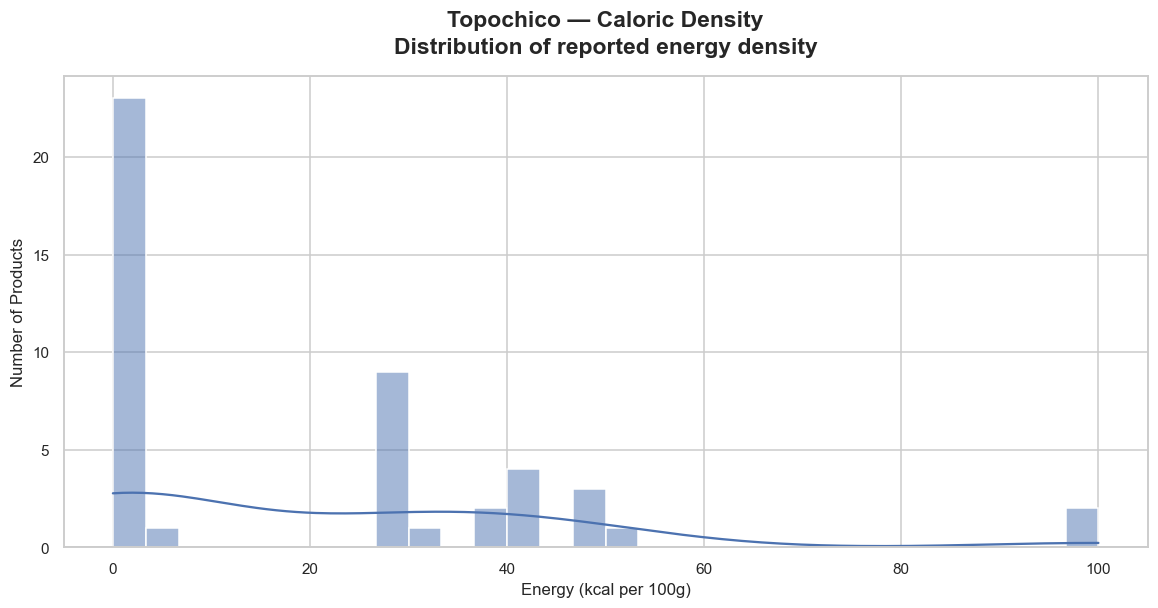


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
Energy values are available for 46 records (56.8% coverage). The median reported
caloric density is 3.9 kcal/100g, while the mean is 20.7 kcal/100g. Missing
measurements limit portfolio-wide inference.



In [31]:
tc.caloric_density()

##### Nutri-Score Rating

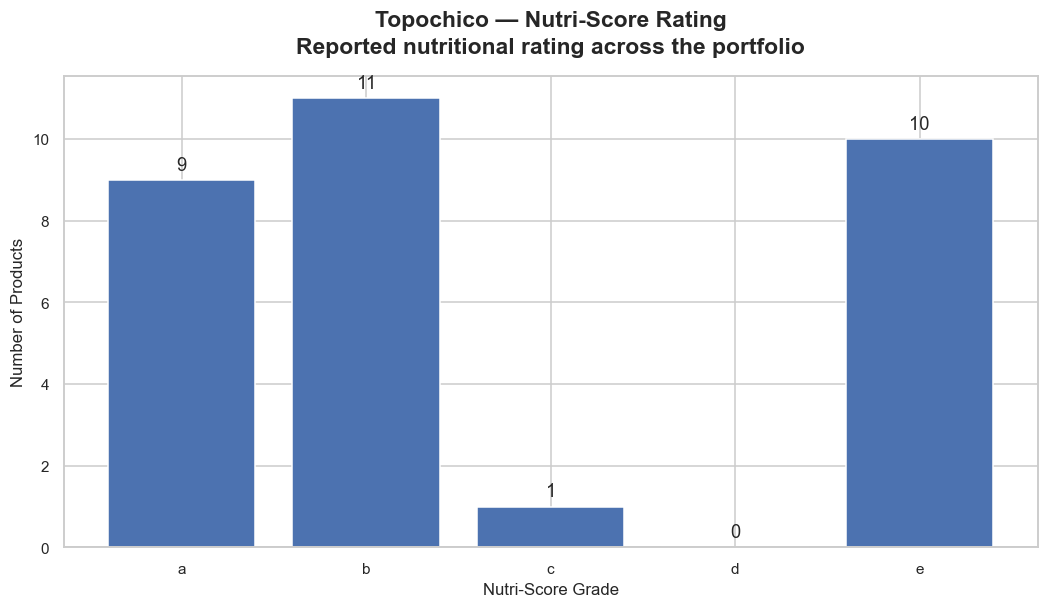


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
Nutri-Score is available for 44 of 81 records (54.3% coverage). The most frequent
reported grade is NOT-APPLICABLE. Unknown or unreported values are excluded from the
grade comparison rather than treated as a nutritional rating.



In [27]:
tc.nutriscore_rating()

#### 1.3 Formulation & Processing

##### NOVA Processing Level

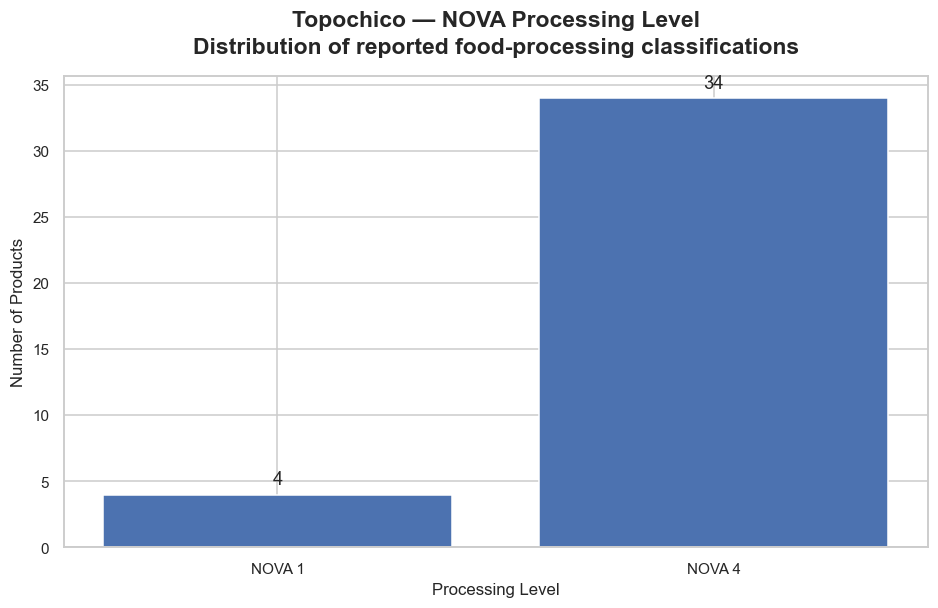


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
NOVA classification is available for 38 of 81 records (46.9% coverage). NOVA group 4
is the most frequently reported processing category. Because NOVA data is incomplete,
this should not be interpreted as a complete classification of the entire portfolio.



In [28]:
tc.nova_processing_level()

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

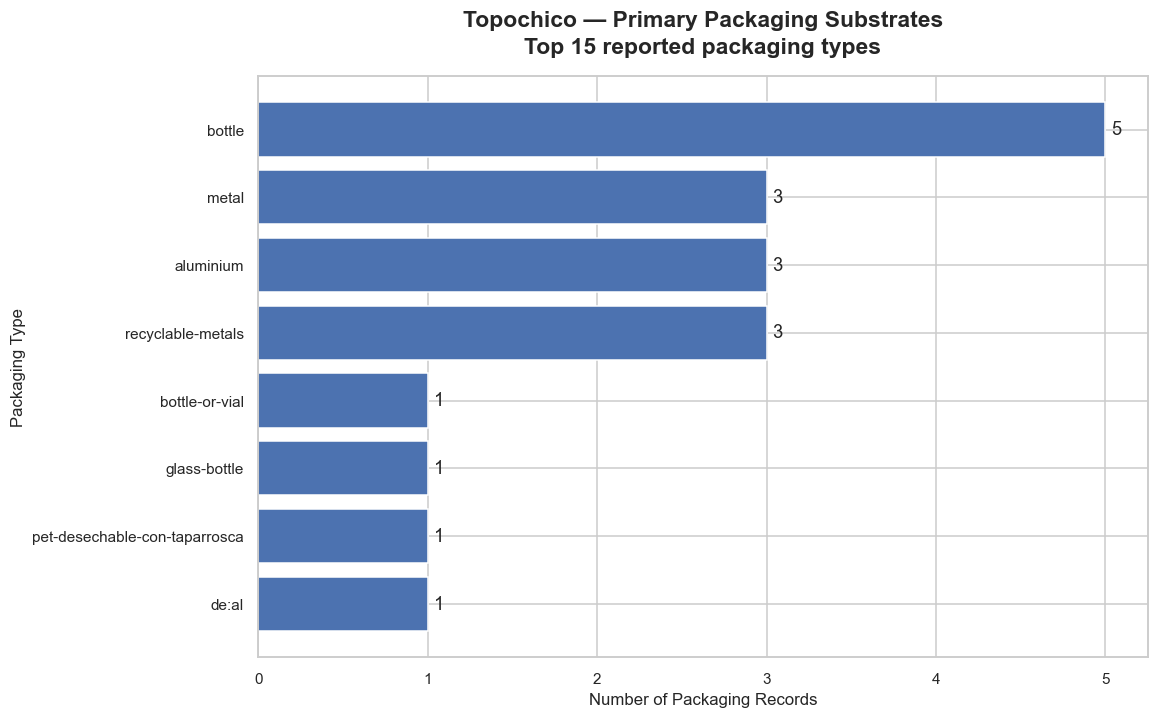


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
The most frequently reported packaging tag is 'bottle'. Packaging metadata contains
multiple detailed format and material tags, so these counts represent reported
catalog metadata rather than physical packaging volumes.



In [29]:
tc.packaging_substrates()

##### Environmental Data Transparency (Eco-Score)

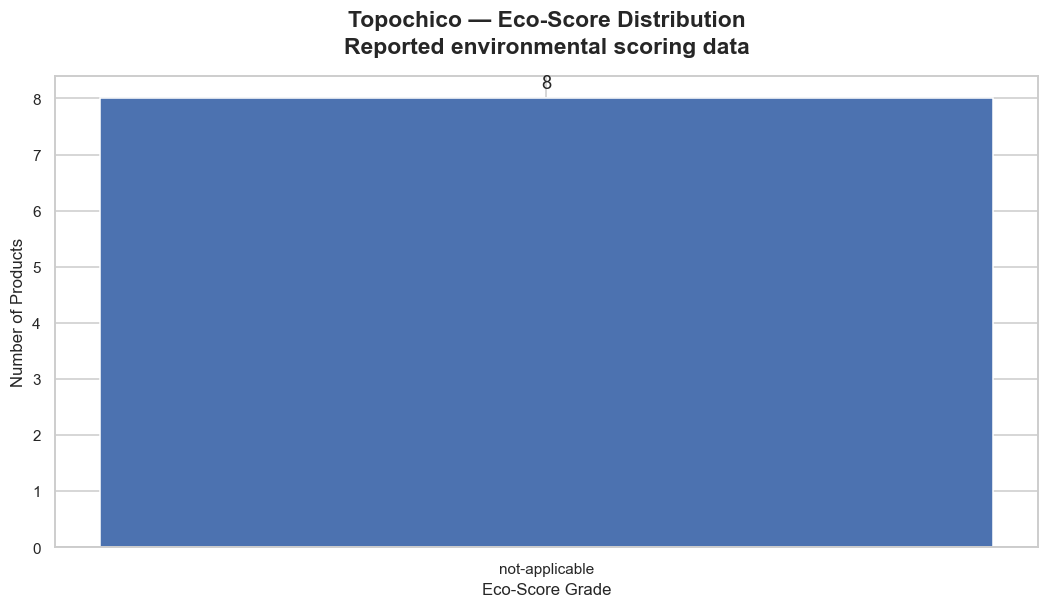


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
Eco-Score information is available for 8 of 81 records (9.9% coverage). 73 records do
not contain a usable Eco-Score grade. Therefore, data availability itself is an
important indicator of environmental-data transparency in the catalog.



In [32]:
tc.ecoscore_transparency()

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

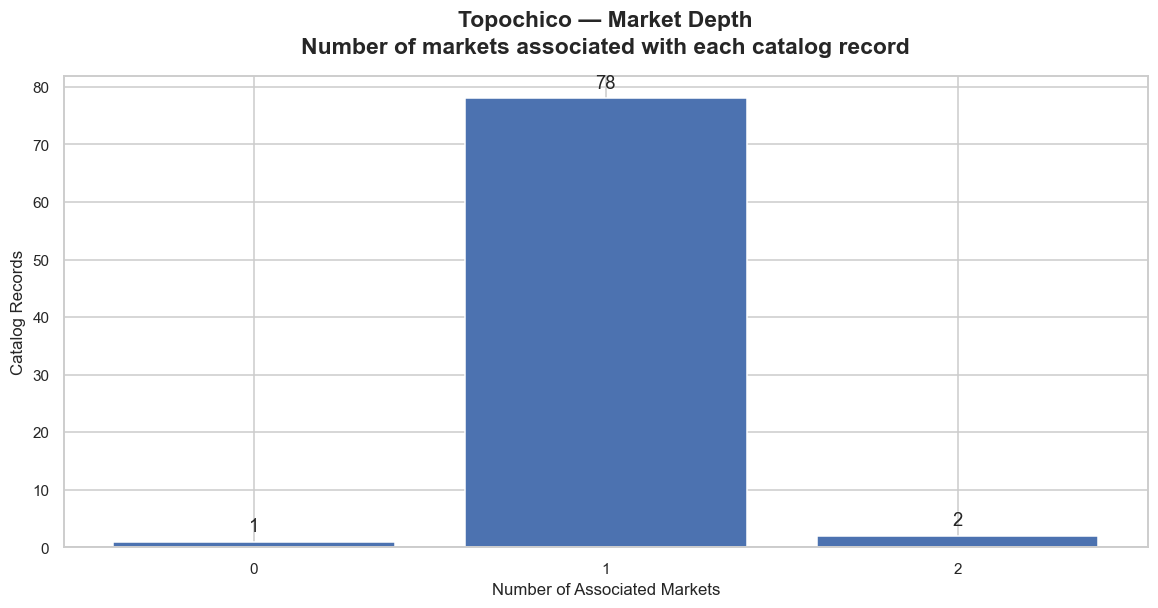


---------------------------------------------------------------------------
INSIGHT
---------------------------------------------------------------------------
This analysis measures how many country tags are associated with each catalog record.
A record linked to one country is more localized in the dataset, while records linked
to multiple countries have broader geographic tagging. This does not independently
establish formulation equivalence.



In [33]:
tc.formulation_market_depth()

## Section 2: Geographic Overview
Catalog Variations across Various Countries

### Brand: Coca-Cola

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Fairlife

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Fanta

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Maaza

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Minute Maid

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Schweppes

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Sprite

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Topo Chico

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

## Section 3: Health & Nutrition Differences Across Regions

### Brand: Coca-Cola

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Fairlife

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Fanta

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Maaza

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Minute Maid

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Schweppes

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Sprite

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Topo Chico

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

## Section 4: Formulation & Processing Across Regions

### Brand: Coca-Cola

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Fairlife

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Fanta

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Maaza

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Minute Maid

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Schweppes

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Sprite

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Topo Chico

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

## Section 5: Packaging Preferences Across Regions

### Brand: Coca-Cola

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Fairlife

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Fanta

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Maaza

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Minute Maid

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Schweppes

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Sprite

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Topo Chico

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

## Section 6: Limitations, Methodology & Strategic Conclusions